In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:

df = pd.read_csv("merged_clean_data.csv")
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,...,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,state,avg_unemployment_rate,unemployment_group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,...,Yes,Express,Yes,Yes,14,Venmo,Fortnightly,Kentucky,6.534397,High
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,...,Yes,Express,Yes,Yes,2,Cash,Fortnightly,Maine,5.631738,Medium
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,...,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Massachusetts,5.543794,Medium
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,...,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Rhode Island,6.385993,Medium
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,...,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Oregon,6.847163,High


In [3]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isna().sum())

Shape: (3900, 21)

Missing values:
 customer_id               0
age                       0
gender                    0
item_purchased            0
category                  0
purchase_amount_(usd)     0
location                  0
size                      0
color                     0
season                    0
review_rating             0
subscription_status       0
shipping_type             0
discount_applied          0
promo_code_used           0
previous_purchases        0
payment_method            0
frequency_of_purchases    0
state                     0
avg_unemployment_rate     0
unemployment_group        0
dtype: int64


In [4]:
df.describe(include="all")

,customer_id,age,gender,item_purchased,category,purchase_amount_(usd),location,size,color,season,...,subscription_status,shipping_type,discount_applied,promo_code_used,previous_purchases,payment_method,frequency_of_purchases,state,avg_unemployment_rate,unemployment_group
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,...,3900,3900,3900,3900,3900.000000,3900,3900,3900,3900.000000,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,...,2,6,2,2,NaN,6,7,50,NaN,3
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,...,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months,Montana,NaN,Low
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,...,2847,675,2223,2223,NaN,677,584,96,NaN,1375
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25.351538,NaN,NaN,NaN,5.836739,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,14.447125,NaN,NaN,NaN,1.066561,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,3.444149,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.000000,NaN,NaN,NaN,5.161259,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,25.000000,NaN,NaN,NaN,5.901064,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,38.000000,NaN,NaN,NaN,6.684752,NaN


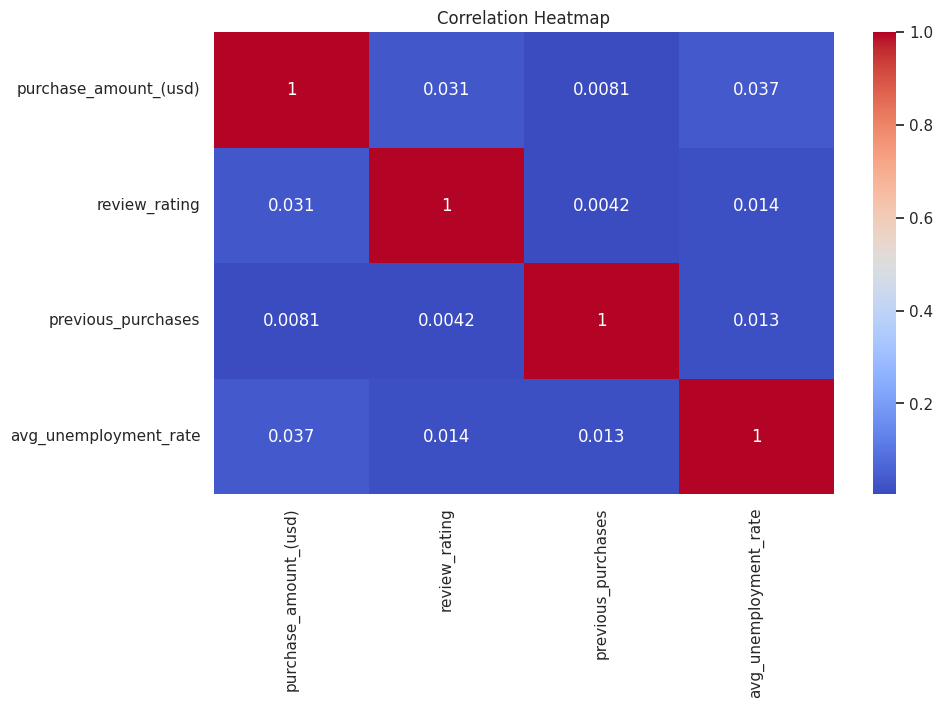

In [5]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[["purchase_amount_(usd)", "review_rating", "previous_purchases", "avg_unemployment_rate"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

In [6]:
## H1-related Exploration: Unemployment Rate vs Spending (boxplot&scatter plot)

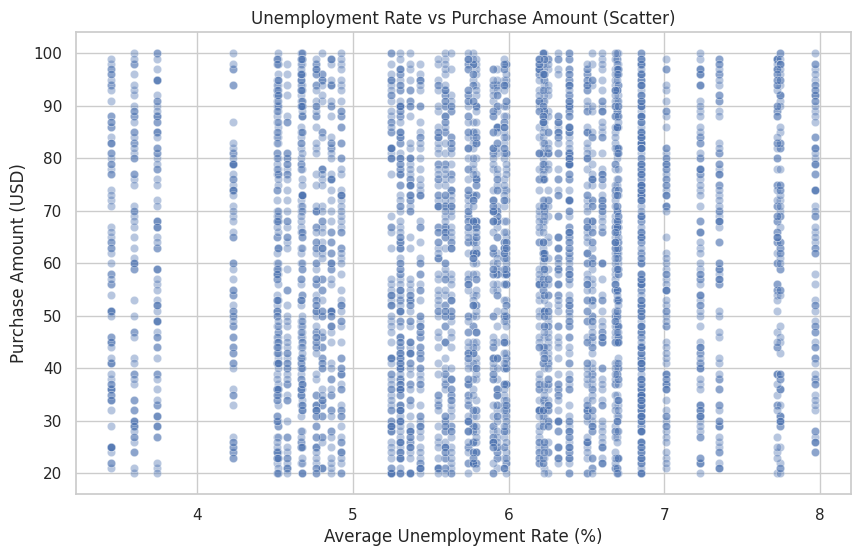

In [7]:
sns.scatterplot(
    data=df,
    x="avg_unemployment_rate",
    y="purchase_amount_(usd)",
    alpha=0.4
)
plt.title("Unemployment Rate vs Purchase Amount (Scatter)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Purchase Amount (USD)")
plt.show()

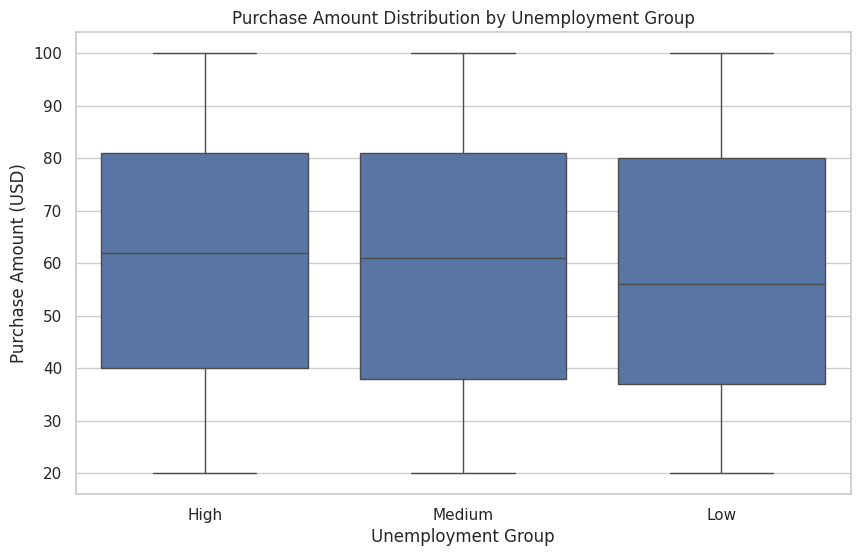

In [8]:
sns.boxplot(
    data=df,
    x="unemployment_group",
    y="purchase_amount_(usd)"
)
plt.title("Purchase Amount Distribution by Unemployment Group")
plt.xlabel("Unemployment Group")
plt.ylabel("Purchase Amount (USD)")
plt.show()

In [9]:
## H2-related Exploration: Unemployment Rate vs Purchase Frequency

In [10]:
#frequency mapping

freq_map = {
    "Daily": 30,
    "Weekly": 4,
    "Bi-Weekly": 2,
    "Fortnightly": 2,
    "Monthly": 1,
    "Quarterly": 0.33,
    "Semi-Annually": 0.16,
    "Annually": 0.083
}

df["purchase_frequency_numeric"] = df["frequency_of_purchases"].map(freq_map)
df[["frequency_of_purchases", "purchase_frequency_numeric"]].head()

,frequency_of_purchases,purchase_frequency_numeric
0,Fortnightly,2.000
1,Fortnightly,2.000
2,Weekly,4.000
3,Weekly,4.000
4,Annually,0.083


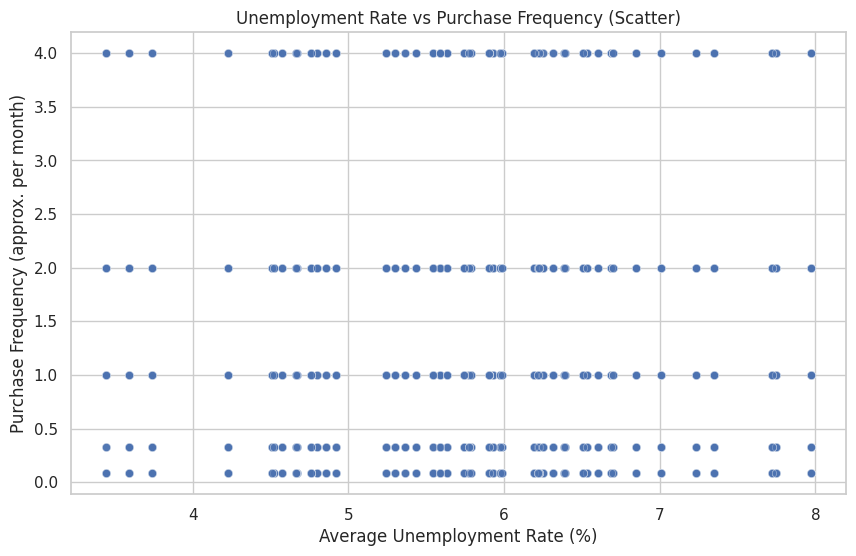

In [11]:
sns.scatterplot(
    data=df,
    x="avg_unemployment_rate",
    y="purchase_frequency_numeric",
    alpha=0.4
)
plt.title("Unemployment Rate vs Purchase Frequency (Scatter)")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("Purchase Frequency (approx. per month)")
plt.show()

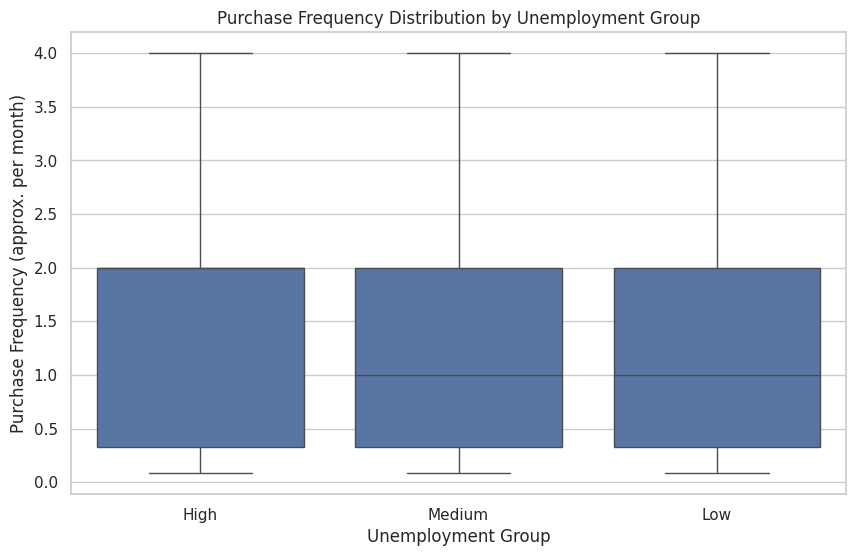

In [12]:
sns.boxplot(
    data=df,
    x="unemployment_group",
    y="purchase_frequency_numeric"
)
plt.title("Purchase Frequency Distribution by Unemployment Group")
plt.xlabel("Unemployment Group")
plt.ylabel("Purchase Frequency (approx. per month)")
plt.show()